In [15]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/zebaakther24/ecommerce-customer-segmentation/ecommerce customer segmentation_unsupervised.csv


Dataset Loaded ✅


,TransactionID,CustomerID,Product,Category,Price,Quantity,PaymentType,City,Country,TransactionDate,DiscountApplied,Rating,Browser,Device,SessionDuration,CouponCode,ReturnStatus,Warehouse,ShippingType,ReviewText
0,735,1288,Dress,Electronics,59580,2,UPI,Hyderabad,India,NaN,Yes,2.925896,Chrome,Mobile,179,OFF20,NaN,WH1,NaN,Good
1,3568,1600,Headphones,NaN,73051,3,UPI,Hyderabad,India,April 5 2023,N,2.375202,Safari,Tablet,383,NaN,Returned,NaN,Standard,Good
2,2647,1750,Laptop,Fashion,41671,1,Cash,NaN,IND,NaN,No,4.847437,Safari,NaN,257,YIrSES,Not Returned,WH2,Express,NaN
3,3636,1744,Mobile,Fashion,77354,3,Cash,NaN,IND,NaN,No,1.304575,NaN,Mobile,373,YIrSES,NaN,NaN,Standard,Bad
4,2323,1246,Dress,Accessories,13351,1,Cash,Delhi,IN,2023-01-01,NaN,4.199372,Edge,Mobile,298,OFF20,Not Returned,NaN,NaN,NaN


Data Cleaning Done ✅
RFM Created ✅


,Recency,Frequency,Monetary
CustomerID,,,
1006,0.0,1,152535
1016,0.0,1,131448
1030,0.0,1,209504
1042,0.0,1,376216
1047,0.0,1,157238


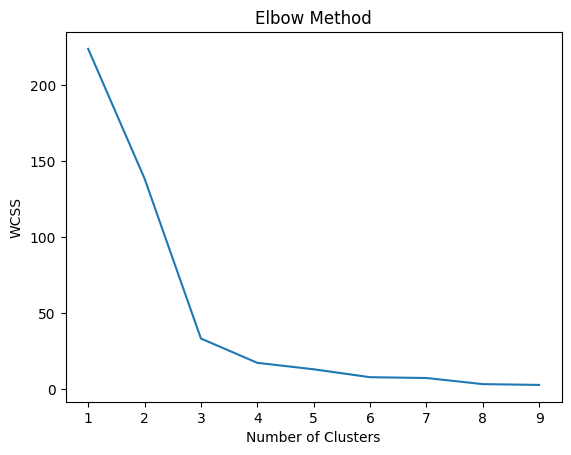

Clustering Done ✅


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
1006,0.0,1,152535,3
1016,0.0,1,131448,3
1030,0.0,1,209504,3
1042,0.0,1,376216,1
1047,0.0,1,157238,3


Cluster Summary:


,Recency,Frequency,Monetary
Cluster,,,
0,0.0,1.0,48618.929825
1,0.0,1.0,292841.052632
2,0.0,2.0,232760.000000
3,0.0,1.0,162105.156250


Silhouette Score: 0.6304252737335422
Top Apriori Rules:


,antecedents,consequents,support,confidence,lift


Top FP-Growth Rules:


,antecedents,consequents,support,confidence,lift


PROJECT COMPLETED SUCCESSFULLY 🚀


In [18]:
# ============================================================
# STEP 0: REMOVE WARNINGS
# ============================================================
import warnings
warnings.filterwarnings("ignore")


# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

# Install mlxtend (Kaggle)
!pip install mlxtend

from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth


# ============================================================
# STEP 2: LOAD DATA
# ============================================================
df = pd.read_csv("/kaggle/input/datasets/zebaakther24/ecommerce-customer-segmentation/ecommerce customer segmentation_unsupervised.csv")

print("Dataset Loaded ✅")
display(df.head())


# ============================================================
# STEP 3: DATA CLEANING
# ============================================================
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# Convert date column
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')

# Create Total Amount
df['TotalAmount'] = df['Quantity'] * df['Price']

print("Data Cleaning Done ✅")


# ============================================================
# STEP 4: FEATURE ENGINEERING (RFM)
# ============================================================
latest_date = df['TransactionDate'].max()

df['Recency'] = (latest_date - df['TransactionDate']).dt.days

rfm = df.groupby('CustomerID').agg({
    'Recency': 'min',
    'TransactionID': 'count',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

# 🔥 IMPORTANT FIX (NaN issue)
rfm = rfm.fillna(0)

print("RFM Created ✅")
display(rfm.head())


# ============================================================
# STEP 5: FEATURE SCALING
# ============================================================
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)


# ============================================================
# STEP 6: ELBOW METHOD
# ============================================================
wcss = []

for i in range(1, 10):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(rfm_scaled)
    wcss.append(km.inertia_)

plt.figure()
plt.plot(range(1,10), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


# ============================================================
# STEP 7: KMEANS CLUSTERING
# ============================================================
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("Clustering Done ✅")
display(rfm.head())


# ============================================================
# STEP 8: CLUSTER ANALYSIS
# ============================================================
print("Cluster Summary:")
display(rfm.groupby('Cluster').mean())


# ============================================================
# STEP 9: MODEL EVALUATION
# ============================================================
score = silhouette_score(rfm_scaled, rfm['Cluster'])
print("Silhouette Score:", score)


# ============================================================
# STEP 10: ASSOCIATION RULE LEARNING
# ============================================================

# Basket creation
basket = df.groupby(['TransactionID', 'Product'])['Quantity'] \
           .sum().unstack().fillna(0)

# Convert to binary
basket = basket.applymap(lambda x: 1 if x > 0 else 0)


# -------- APRIORI --------
frequent_items = apriori(basket, min_support=0.02, use_colnames=True)

rules = association_rules(frequent_items, metric="lift", min_threshold=1)

print("Top Apriori Rules:")
display(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())


# -------- FP-GROWTH --------
frequent_items_fp = fpgrowth(basket, min_support=0.02, use_colnames=True)

rules_fp = association_rules(frequent_items_fp, metric="lift", min_threshold=1)

print("Top FP-Growth Rules:")
display(rules_fp[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())


# ============================================================
# 🎉 PROJECT COMPLETED
# ============================================================
print("PROJECT COMPLETED SUCCESSFULLY 🚀")

import pickle

pickle.dump(kmeans, open("kmeans.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))